# RFM analysis of sample sales data

## 1. Problem Definition

We will analyze a dummy dataset 'sales_data.csv' to illustrate RFM analysis steps. This dataset contains transactional data from a retail store, including customer IDs, purchase dates, and purchase amounts. The goal is to identify key customer segments and their behaviors based on RFM metrics.

**Key Questions:**
  - Which customers are the most valuable based on their purchasing behavior?
  - How can we target specific customer segments with tailored marketing strategies?
  - What insights can we gain to improve customer retention and loyalty?

## 2. Retrieving Data

In [1]:
from pathlib import Path
import pandas as pd
source_path = Path.cwd() / '..' / 'csv' / 'sales_data.csv'
sales_df = pd.read_csv(source_path)
sales_df.head()

,CustomerID,OrderDate,Amount
0,C0022,2024-01-01,131.05
1,C0063,2024-01-01,26.88
2,C0081,2024-01-01,279.32
3,C0082,2024-01-01,203.65
4,C0012,2024-01-01,98.03


## 3. Data Preparation
#### 3-1 Compute R, F, M values for each customer.

In [4]:
import datetime as dt

ref_date = dt.datetime(2024, 12, 31)

rfm = sales_df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (ref_date - pd.to_datetime(x).max()).days,  # Recency
    'CustomerID': 'count',  # Frequency
    'Amount': 'sum'         # Monetary
}).rename(columns={'OrderDate':'Recency', 'CustomerID':'Frequency', 'Amount':'Monetary'})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
C0001,196,7,890.17
C0002,129,8,927.04
C0003,304,9,1016.88
C0004,52,14,1171.80
C0005,281,2,274.29


In [9]:
# Assign RFM Scores
# pd.qcut() divides a continuous numerical variable into equal-frequency bins — meaning each bin contains (as much as possible) the same number of observations.
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]) 
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
# rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
C0001,196,7,890.17,4,3,3,433,10
C0002,129,8,927.04,5,4,4,544,13
C0003,304,9,1016.88,1,4,4,144,9
C0004,52,14,1171.80,5,5,5,555,15
C0005,281,2,274.29,1,1,1,111,3


#### 3-2 Segment Customers
| RFM_Score | Segment | Description |
|-----------|---------|-------------|
| 13–15    | ⭐ Champions       | Very recent, frequent, high spenders |
| 10–12    | 💎 Loyal Customers | Regular buyers |
| 7–9      | 🕓 Potential Loyalists | May become champions soon |
| 4–6      | ⚠️ At Risk       | Haven’t purchased recently |
| 1–3      | 💀 Lost Customers | Long inactive |


In [ ]:
def label_segment(score):
    if score >= 13:
        return "Champions"
    if score >= 10:
        return "Loyal Customers"
    if score >= 7:
        return "Potential Loyalists"
    if score >= 4:
        return "At Risk"
    return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(label_segment)
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
CustomerID,,,,,,,,,
C0001,196,7,890.17,4,3,3,433,10,Loyal Customers
C0002,129,8,927.04,5,4,4,544,13,Champions
C0003,304,9,1016.88,1,4,4,144,9,Potential Loyalists
C0004,52,14,1171.80,5,5,5,555,15,Champions
C0005,281,2,274.29,1,1,1,111,3,Lost


In [11]:
rfm.sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
CustomerID,,,,,,,,,
C0026,98,13,1514.34,5,5,5,555,15,Champions
C0004,52,14,1171.80,5,5,5,555,15,Champions
C0097,165,10,1674.98,5,5,5,555,15,Champions
C0111,100,11,2050.25,5,5,5,555,15,Champions
C0100,116,9,1203.76,5,4,5,545,14,Champions
...,...,...,...,...,...,...,...,...,...
C0011,314,5,503.40,1,1,1,111,3,Lost
C0035,293,5,478.44,1,1,1,111,3,Lost
C0005,281,2,274.29,1,1,1,111,3,Lost


## 4. Exploratory Data Analysis (EDA)
Understand RFM analysis through visualizations

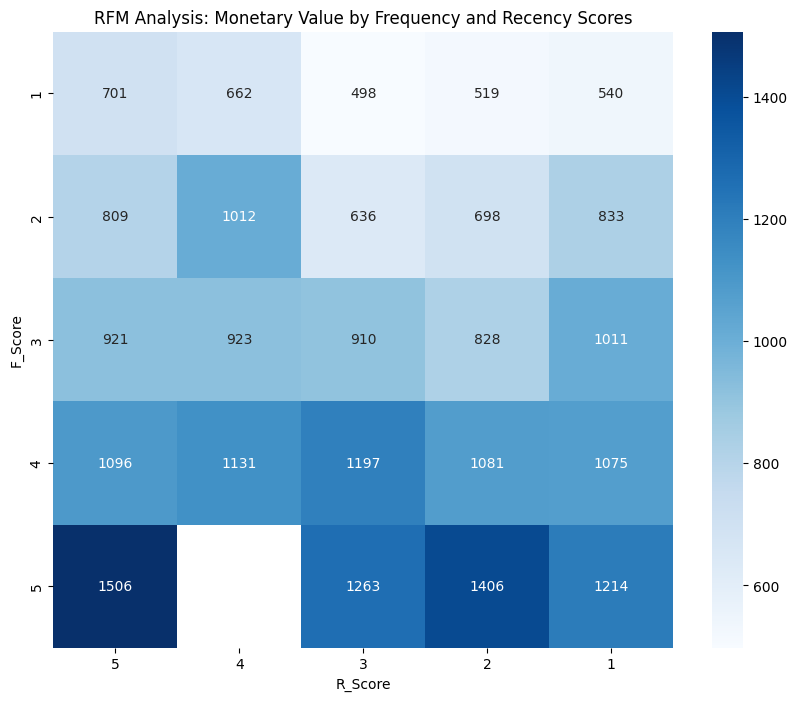

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the heatmap with proper number formatting
plt.figure(figsize=(10, 8))
sns.heatmap(rfm.pivot_table(index='F_Score', columns='R_Score', values='Monetary', observed=False), 
            annot=True, fmt='.0f', cmap='Blues')
plt.title('RFM Analysis: Monetary Value by Frequency and Recency Scores')
plt.show()

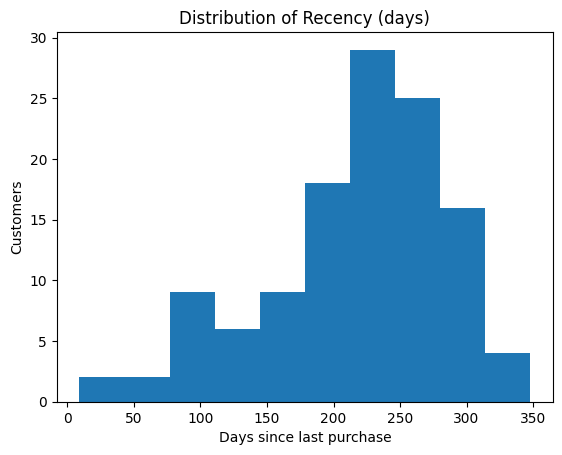

In [44]:
# Charts of distribution of Recency
rfm["Recency"].plot(kind="hist", bins=10)
plt.title("Distribution of Recency (days)")
plt.xlabel("Days since last purchase")
plt.ylabel("Customers")
plt.show()

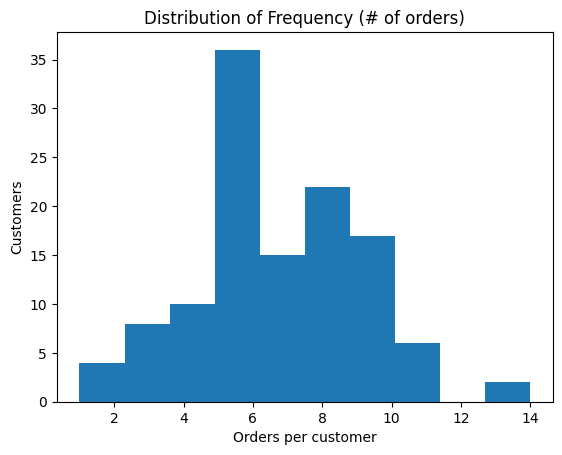

In [47]:
# Charts of distribution of Frequency
rfm["Frequency"].plot(kind="hist", bins=10)
plt.title("Distribution of Frequency (# of orders)")
plt.xlabel("Orders per customer")
plt.ylabel("Customers")
plt.show()

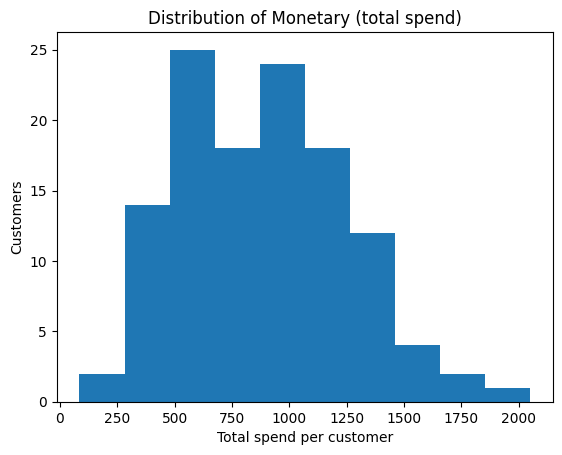

In [50]:
# Charts of distribution of Monetary
rfm["Monetary"].plot(kind="hist", bins=10)
plt.title("Distribution of Monetary (total spend)")
plt.xlabel("Total spend per customer")
plt.ylabel("Customers")
plt.show()

## 6. Results & Next Steps
`What we learned:`

- High R, Low F: New customers with potential - nurture for loyalty
- Low R, High F: Previously loyal customers at risk - re-engagement campaigns
- Low R, Low F: Lost customers - win-back or ignore
- High R, High F: Champions - VIP treatment and referral programs
- A right-skewed distribution of 'recency' suggests few recent customers. It maybe unhealthy

`Next Steps:`

- Implement targeted marketing strategies for high-performing VIPs
- Design retention program to avoid customer lost
- Conduct further analysis on why recency is so long